<a href="https://colab.research.google.com/github/Bouchask/Bouchak-yahya/blob/main/ml_projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yahyab3","key":"718632714d166764f7ac718992bb8d12"}'}

In [2]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

# Set correct permissions
os.chmod("/root/.kaggle/kaggle.json", 0o600)


In [3]:
!kaggle --version


Kaggle API 1.7.4.5


In [4]:
!kaggle datasets download -d blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
  0% 0.00/172k [00:00<?, ?B/s]
100% 172k/172k [00:00<00:00, 957MB/s]


In [5]:
!unzip telco-customer-churn.zip

Archive:  telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [6]:
import pandas as pd
data_csv = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.DataFrame(data_csv)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
# extracte feature to type  object but is bool in original version
# Identify columns that are Type 'Object' AND have exactly 2 unique values
binary_cols = [col for col in df.select_dtypes(include=['object']).columns
               if df[col].nunique() == 2]

print("Found Boolean-like String Columns:", binary_cols)

Found Boolean-like String Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']


In [10]:
# extracte feature to type  object but is classes  in original version
# Identify columns that are Type 'Object' AND have exactly 2 unique values
classes_cols = [col for col in df.select_dtypes(include=['object']).columns
               if 2 < df[col].nunique() < 20]

print("Found Boolean-like String Columns:", classes_cols)

Found Boolean-like String Columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [11]:
from sklearn.preprocessing import LabelEncoder
df_encoder = df.copy()
for col in binary_cols:
    df_encoder[col] = LabelEncoder().fit_transform(df_encoder[col])
df_encoder.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [12]:
from sklearn.preprocessing import OneHotEncoder
df_encoder = df_encoder.copy()
for col in classes_cols:
    df_encoder[col] = LabelEncoder().fit_transform(df_encoder[col])
df_encoder.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [13]:
df_encoder

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1990.5,0
7039,2234-XADUH,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,7362.9,0
7040,4801-JZAZL,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,346.45,0
7041,8361-LTMKD,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,306.6,1


In [14]:
df_encoder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   int64  
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   int64  
 16  PaperlessBilling  7043 non-null   int64  


In [15]:
import numpy as np

df_encoder["TotalCharges"] = (
    df_encoder["TotalCharges"]
    .str.strip()                          # remove spaces
    .replace("", np.nan)                 # empty string -> NaN
    .astype(float)
)
df_encoder["TotalCharges"].fillna(
    df_encoder["TotalCharges"].median(),
    inplace=True
)


/tmp/ipython-input-2053644174.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_encoder["TotalCharges"].fillna(


In [16]:
df_encoder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   int64  
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   int64  
 16  PaperlessBilling  7043 non-null   int64  


In [17]:
df_encoder

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1990.50,0
7039,2234-XADUH,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,7362.90,0
7040,4801-JZAZL,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,346.45,0
7041,8361-LTMKD,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,306.60,1


In [18]:
df_encoder.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
# i am drop customerId because  is just index
df_encoder.drop("customerID", axis=1, inplace=True)


In [20]:
df_encoder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


In [21]:
stats = df_encoder.describe().T
stats["variance"] = df_encoder.var()
stats["skewness"] = df_encoder.skew()
stats["kurtosis"] = df_encoder.kurtosis()

stats


,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis
gender,7043.0,0.504756,0.500013,0.00,0.000,1.000,1.00,1.00,2.500129e-01,-0.019031,-2.000206
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.000,0.000,0.00,1.00,1.358745e-01,1.833633,1.362596
Partner,7043.0,0.483033,0.499748,0.00,0.000,0.000,1.00,1.00,2.497476e-01,0.067922,-1.995953
Dependents,7043.0,0.299588,0.458110,0.00,0.000,0.000,1.00,1.00,2.098649e-01,0.875199,-1.234378
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.000,55.00,72.00,6.031681e+02,0.239540,-1.387372
PhoneService,7043.0,0.903166,0.295752,0.00,1.000,1.000,1.00,1.00,8.746938e-02,-2.727153,5.438908
MultipleLines,7043.0,0.940508,0.948554,0.00,0.000,1.000,2.00,2.00,8.997548e-01,0.118719,-1.878378
InternetService,7043.0,0.872923,0.737796,0.00,0.000,1.000,1.00,2.00,5.443434e-01,0.205423,-1.145505
OnlineSecurity,7043.0,0.790004,0.859848,0.00,0.000,1.000,2.00,2.00,7.393377e-01,0.416985,-1.520966
OnlineBackup,7043.0,0.906432,0.880162,0.00,0.000,1.000,2.00,2.00,7.746860e-01,0.182930,-1.684892


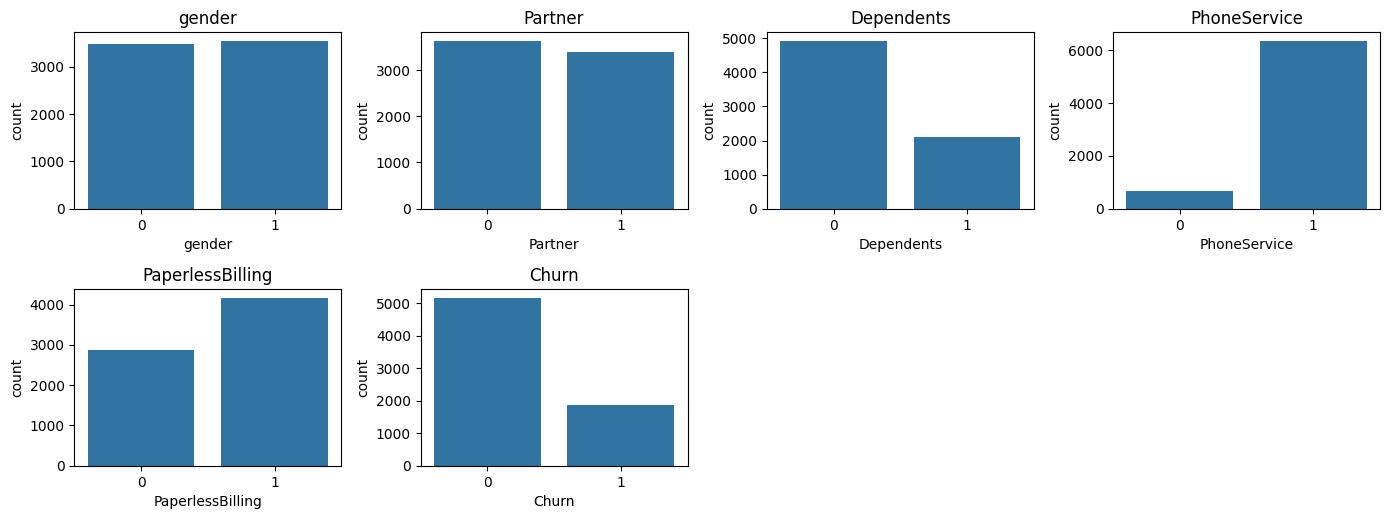

In [22]:
#i want to Visualize binary distributions
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

for i, col in enumerate(binary_cols, 1):
    plt.subplot(4, 4, i)
    sns.countplot(x=df_encoder[col])
    plt.title(col)

plt.tight_layout()
plt.show()


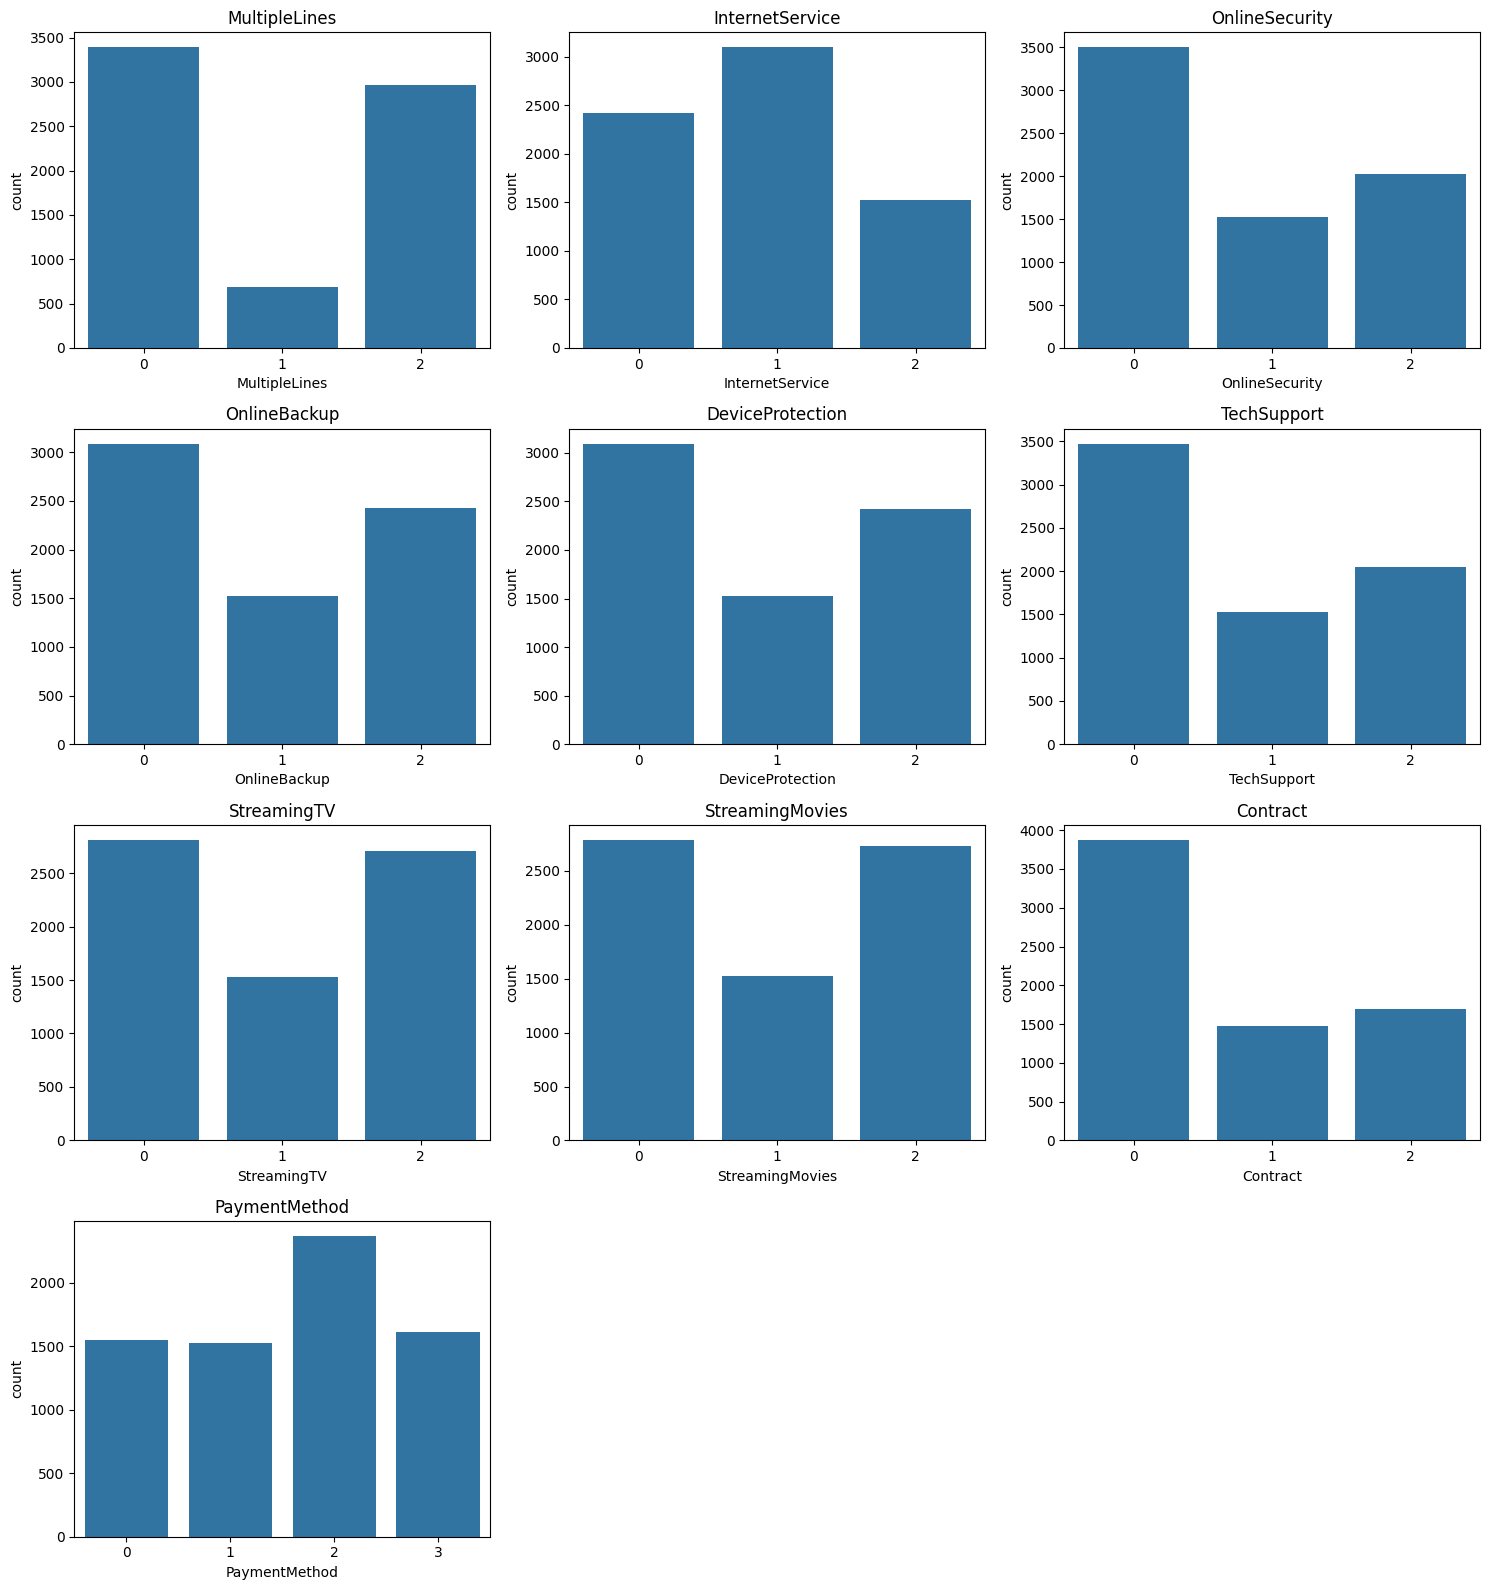

In [23]:
# i want to visualize values for multi-class features
import math
n_cols = 3
n_rows = math.ceil(len(classes_cols) / n_cols)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(classes_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=df_encoder[col])
    plt.title(col)

plt.tight_layout()
plt.show()


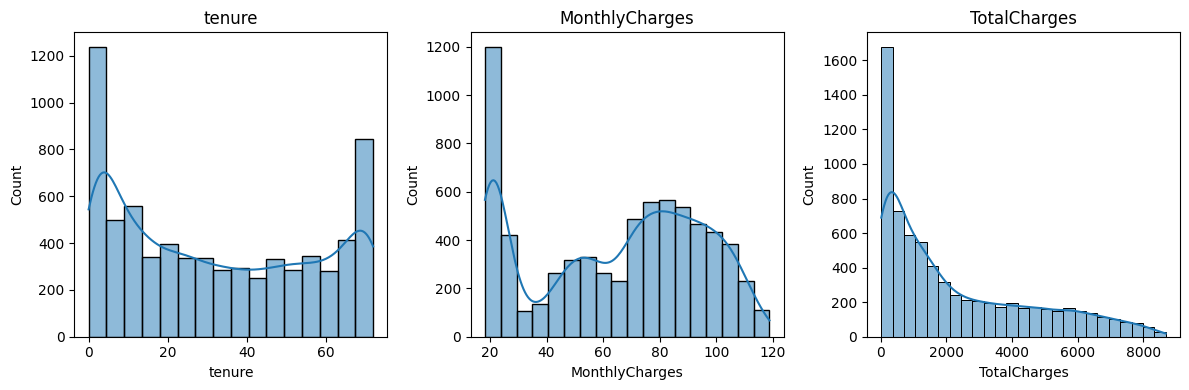

In [24]:
# i want to visualize Distribution of continuous features
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

plt.figure(figsize=(12, 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df_encoder[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()


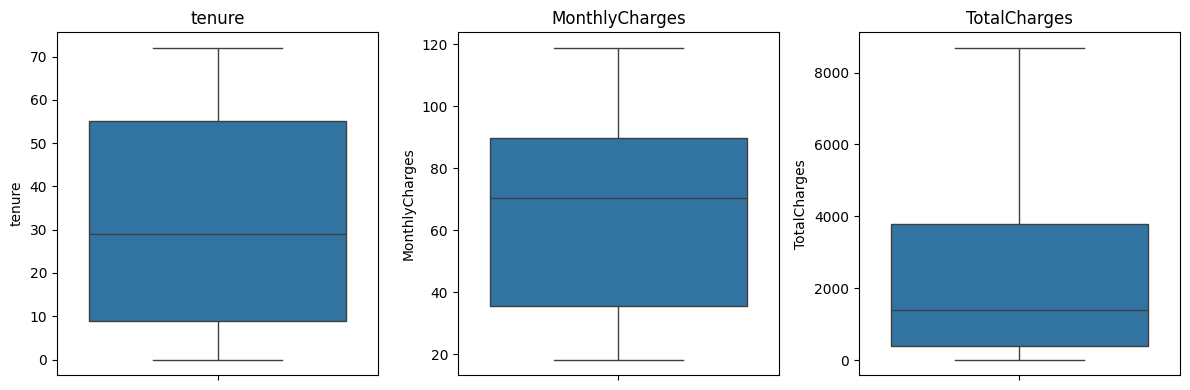

In [25]:
# i want to Boxplots (outlier detection)
plt.figure(figsize=(12, 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_encoder[col])
    plt.title(col)

plt.tight_layout()
plt.show()


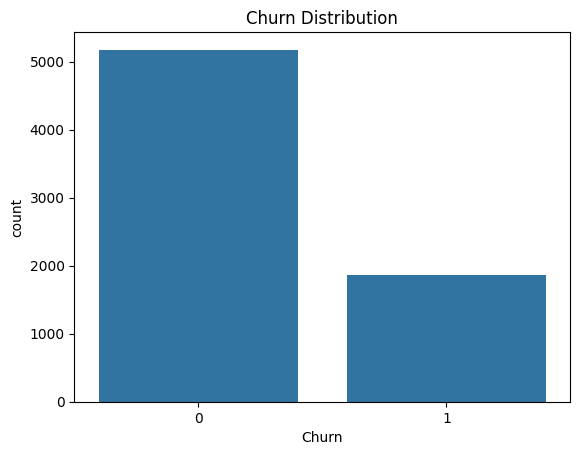

,proportion
Churn,
0,73.463013
1,26.536987


In [26]:
#Churn distribution (target variable)
sns.countplot(x=df_encoder["Churn"])
plt.title("Churn Distribution")
plt.show()
df_encoder["Churn"].value_counts(normalize=True) * 100


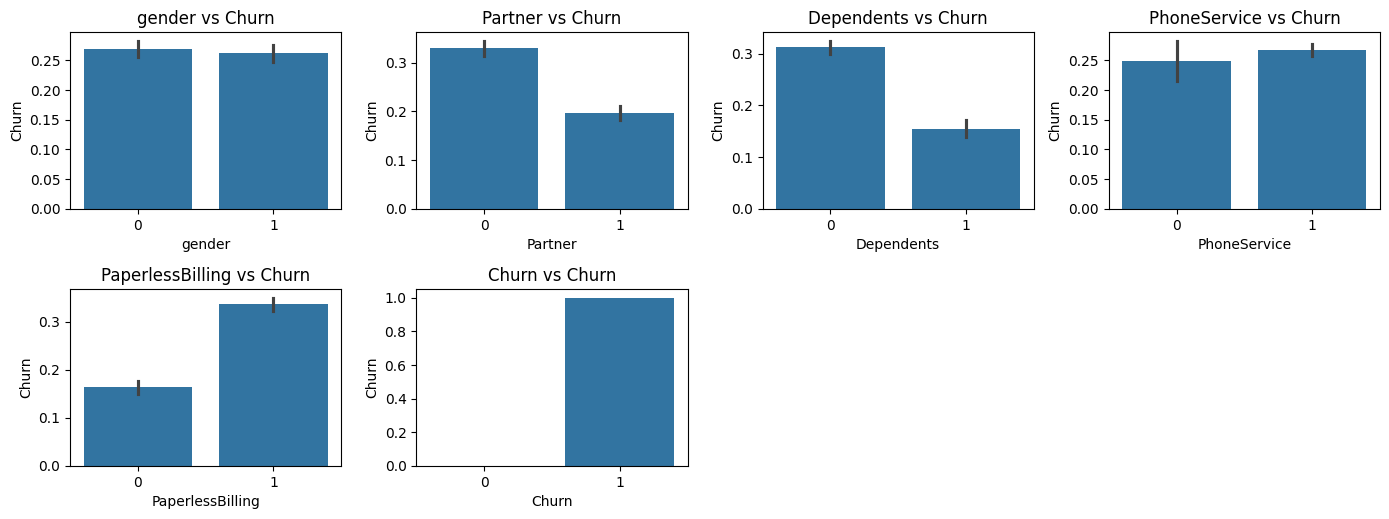

In [27]:
#Feature vs Churn
plt.figure(figsize=(14, 10))

for i, col in enumerate(binary_cols, 1):
    plt.subplot(4, 4, i)
    sns.barplot(x=df_encoder[col], y=df_encoder["Churn"])
    plt.title(f"{col} vs Churn")

plt.tight_layout()
plt.show()


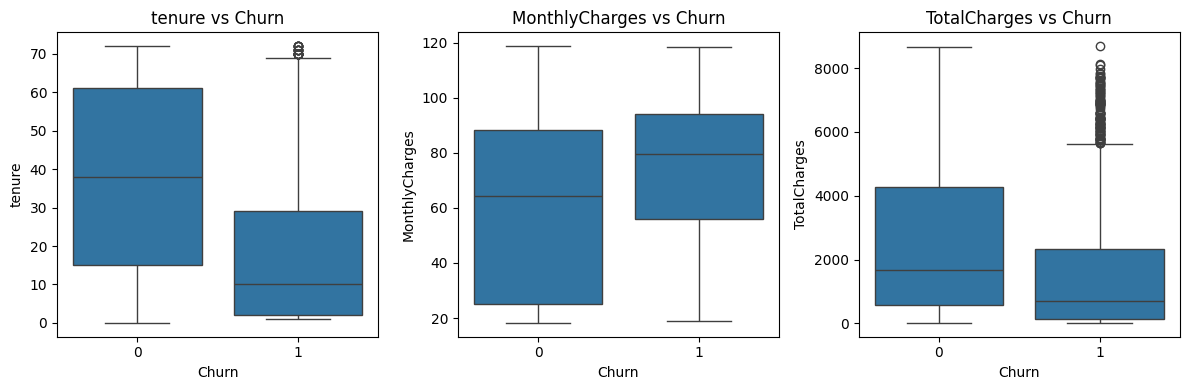

In [28]:
#Continuous features vs churn
plt.figure(figsize=(12, 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df_encoder["Churn"], y=df_encoder[col])
    plt.title(f"{col} vs Churn")

plt.tight_layout()
plt.show()


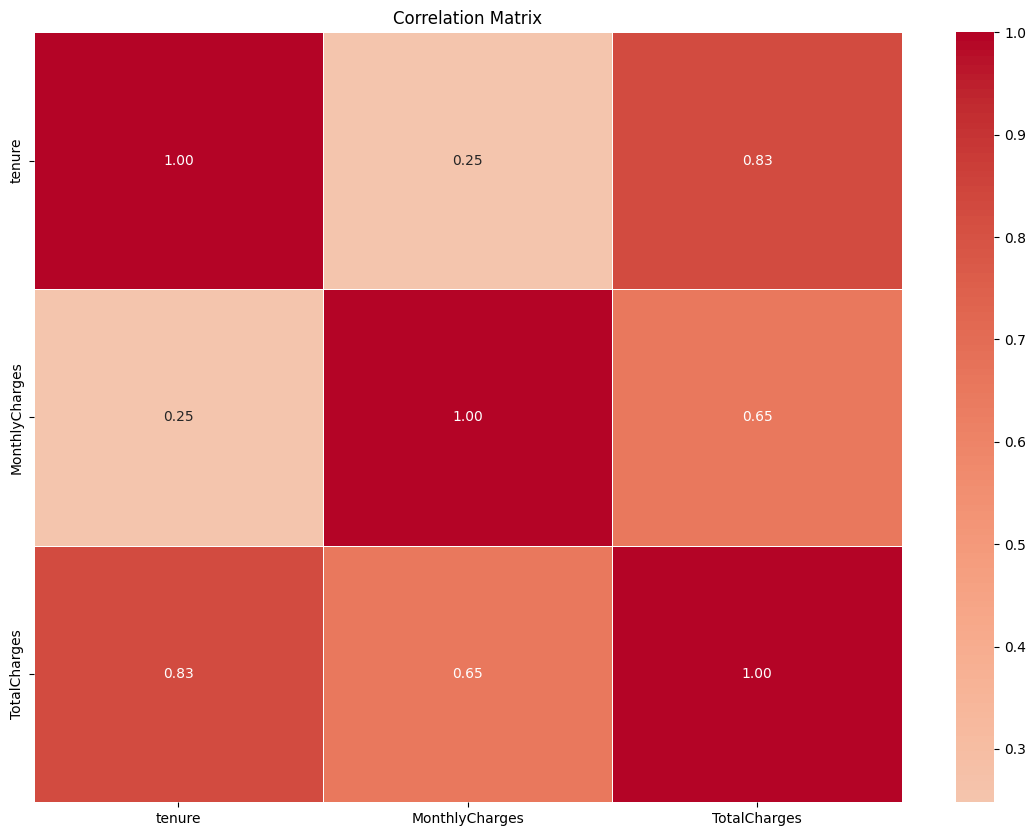

In [29]:
#Correlation matrix (numeric)
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_encoder[numeric_cols].corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()


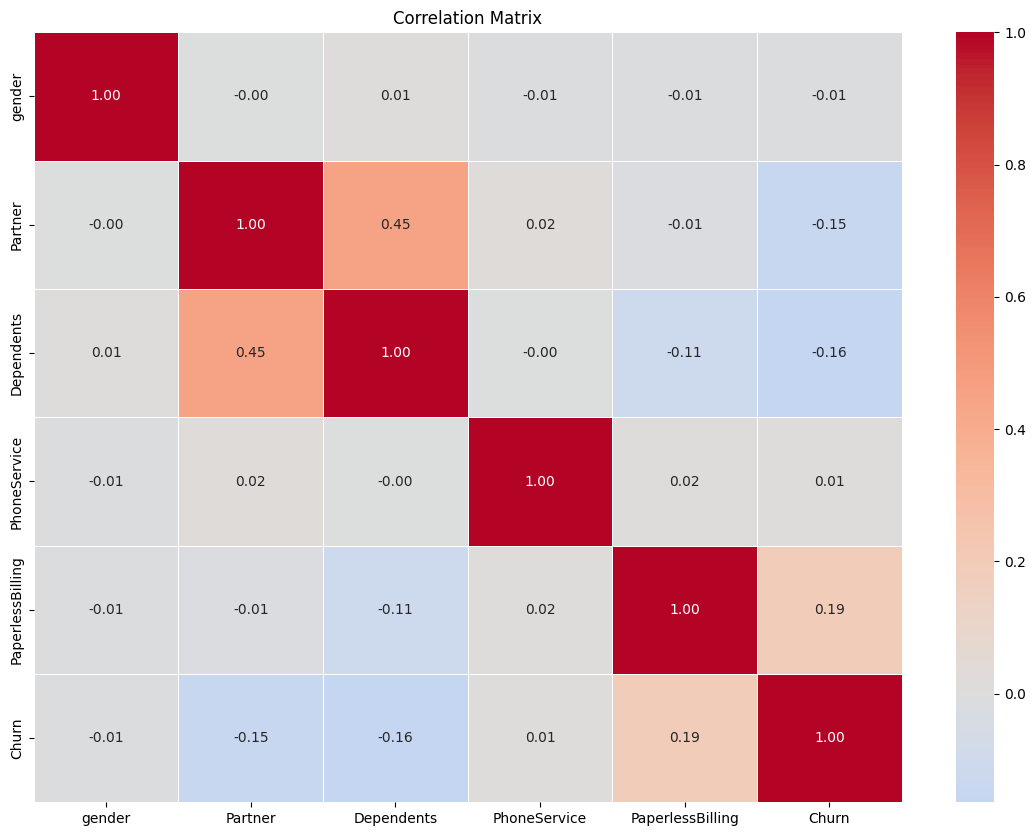

In [30]:
#Correlation matrix (binary)
plt.figure(figsize=(14, 10))
sns.heatmap(
   df_encoder[binary_cols].corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()


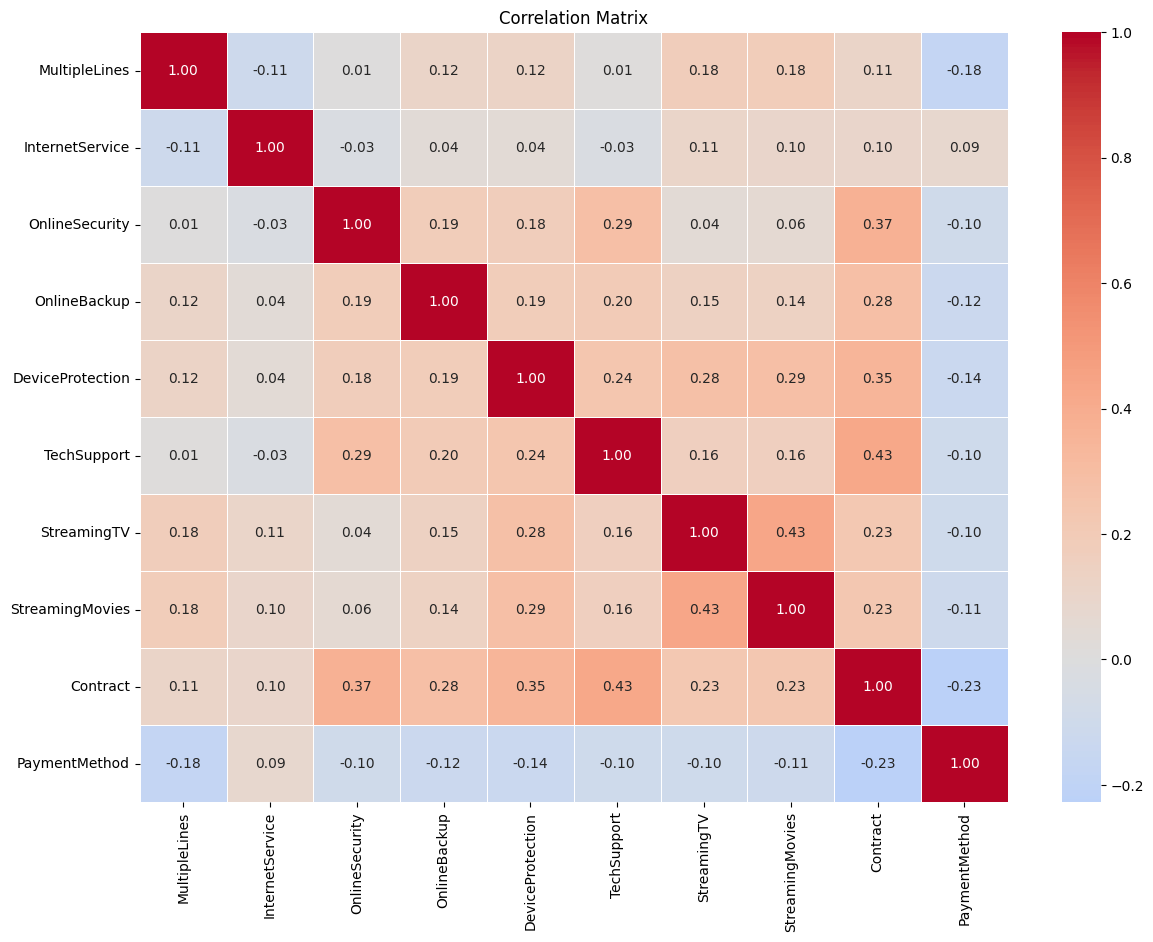

In [31]:
#Correlation matrix (multi-classes)
plt.figure(figsize=(14, 10))
sns.heatmap(
   df_encoder[classes_cols].corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()


In [32]:
#split data
X = df_encoder.drop("Churn", axis=1)
y = df_encoder["Churn"]


In [33]:
#create module minmaxscaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [34]:
from sklearn.feature_selection import SelectKBest, chi2

k = 10  # number of best features you want

chi_selector = SelectKBest(score_func=chi2, k=k)
X_chi = chi_selector.fit_transform(X_scaled, y)


In [35]:
#show feature selected by SelectKBest
selected_features = X.columns[chi_selector.get_support()]
selected_features


Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract',
       'PaperlessBilling'],
      dtype='object')

In [36]:
chi_scores = pd.DataFrame({
    "Feature": X.columns,
    "Chi2_Score": chi_selector.scores_,
    "p_value": chi_selector.pvalues_
}).sort_values(by="Chi2_Score", ascending=False)

chi_scores.head(10)


,Feature,Chi2_Score,p_value
14,Contract,557.890083,2.418791e-123
8,OnlineSecurity,275.805765,6.160514e-62
11,TechSupport,261.651933,7.489253e-59
4,tenure,226.096162,4.233851e-51
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
9,OnlineBackup,115.043260,7.699927e-27
15,PaperlessBilling,105.680863,8.661987e-25
10,DeviceProtection,95.651570,1.369910e-22
2,Partner,82.412083,1.104764e-19


In [37]:
#show data final
X_final = df_encoder[selected_features]
y_final = df_encoder["Churn"]

X_final.head()


,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling
0,0,1,0,1,0,2,0,0,0,1
1,0,0,0,34,2,0,2,0,1,0
2,0,0,0,2,2,2,0,0,0,1
3,0,0,0,45,2,0,2,2,1,0
4,0,0,0,2,0,0,0,0,0,1


In [38]:
# 70% for train and 30% for test and val
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_final,
    y_final,
    test_size=0.30,        # 30% temp
    random_state=42,
    stratify=y_final
)


In [39]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,        # half of 30% = 15%
    random_state=42,
    stratify=y_temp
)


In [40]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (4930, 10)
Validation: (1056, 10)
Test: (1057, 10)


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score, roc_auc_score


In [42]:
X = X_train
y = y_train


In [43]:
#logistic regression
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

param_lr = {
    "model__C": [0.01, 0.1, 1, 10]
}


In [44]:
#svm
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, class_weight="balanced"))
])

param_svm = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"]
}


In [45]:
#knn
from sklearn.neighbors import KNeighborsClassifier

pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

param_knn = {
    "model__n_neighbors": [5, 10, 20],
    "model__weights": ["uniform", "distance"]
}


In [46]:
#random forest
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
])

param_rf = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20]
}


In [47]:
#gridsearch for optimse parametre
models = {
    "LogisticRegression": (pipe_lr, param_lr),
    "SVM": (pipe_svm, param_svm),
    "KNN": (pipe_knn, param_knn),
    "RandomForest": (pipe_rf, param_rf)
}

results = {}
best_models = {}


In [48]:
for name, (pipe, params) in models.items():
    print(f"\nTraining {name} ...")

    grid = GridSearchCV(
        pipe,
        params,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    grid.fit(X, y)

    best_models[name] = grid.best_estimator_

    y_val_pred = grid.best_estimator_.predict(X_val)
    y_val_prob = grid.best_estimator_.predict_proba(X_val)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "ROC_AUC": roc_auc_score(y_val, y_val_prob)
    }

    print("Best params:", grid.best_params_)



Training LogisticRegression ...
Best params: {'model__C': 0.01}

Training SVM ...
Best params: {'model__C': 0.1, 'model__kernel': 'rbf'}

Training KNN ...
Best params: {'model__n_neighbors': 20, 'model__weights': 'uniform'}

Training RandomForest ...
Best params: {'model__max_depth': 10, 'model__n_estimators': 400}


In [49]:
results_df = pd.DataFrame(results).T
results_df.sort_values("ROC_AUC", ascending=False)


,Accuracy,ROC_AUC
LogisticRegression,0.704545,0.808689
SVM,0.707386,0.807182
KNN,0.776515,0.802828
RandomForest,0.741477,0.802430


In [50]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
    plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
    plt.title(title)
    plt.xlabel("Training size")
    plt.ylabel("ROC-AUC")
    plt.legend()
    plt.grid()


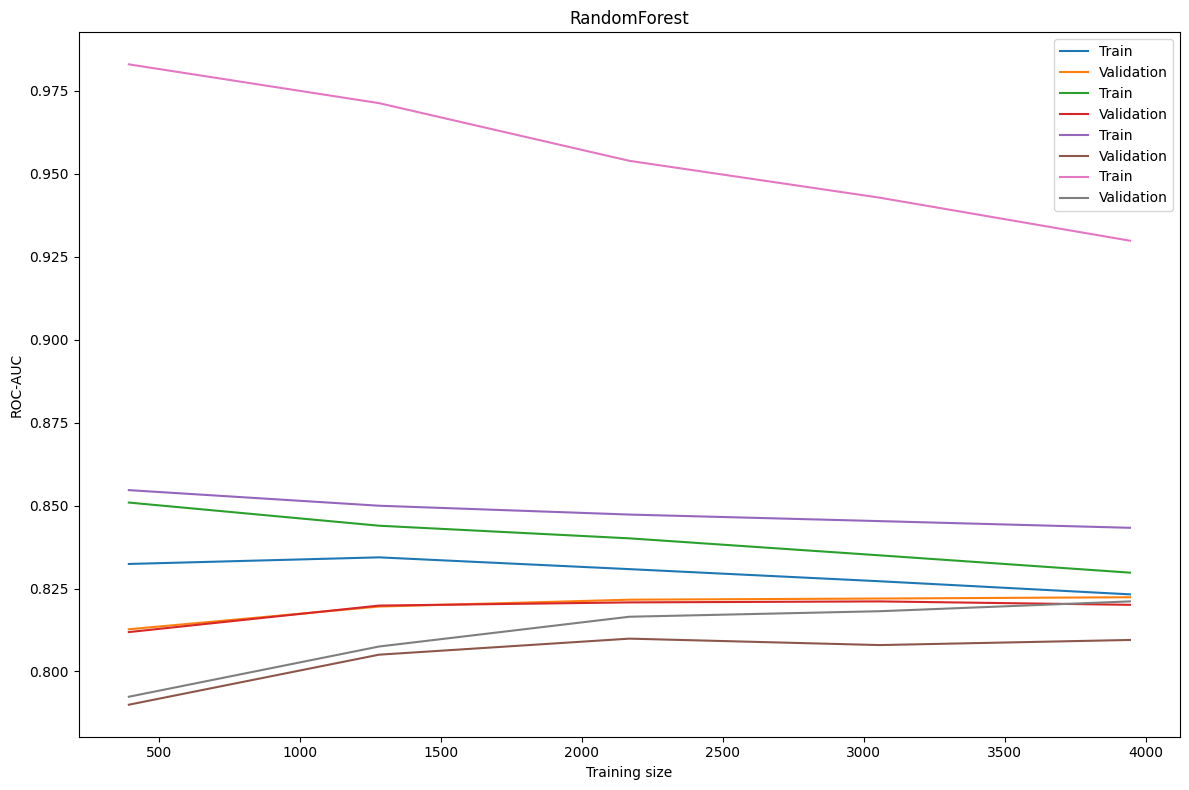

In [51]:
plt.figure(figsize=(12, 8))

for name, model in best_models.items():
    plot_learning_curve(model, X, y, name)

plt.tight_layout()
plt.show()


In [52]:
best_model_name = results_df["ROC_AUC"].idxmax()
best_model = best_models[best_model_name]

print("BEST MODEL:", best_model_name)


BEST MODEL: LogisticRegression


In [53]:
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))


Test Accuracy: 0.7133396404919584
Test ROC-AUC: 0.8236439263308508
